<a href="https://colab.research.google.com/github/Supriya6462/AI-and-Machine-Learning/blob/main/Workshop_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()   # upload your zip file

import zipfile
import os

zip_path = "/content/drive/MyDrive/AI\ML/DATA/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI ML 2026"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))

<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_595/20759937.py:7: SyntaxWarning: invalid escape sequence '\M'
  zip_path = "/content/drive/MyDrive/AI\ML/DATA/FruitinAmazon.zip"


Saving download (1).jpeg to download (1).jpeg
Extracted files: ['DevanagariHandwrittenDigitDataset', 'FruitinAmazon']


#TASK 1: Data Understanding & Visualization

Classes: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


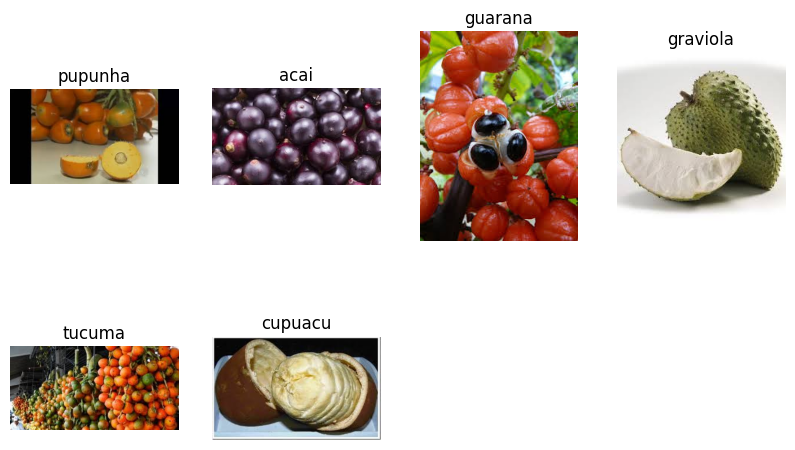

In [26]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train"

classes = os.listdir(train_dir)
print("Classes:", classes)

images = []
titles = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    titles.append(cls)

plt.figure(figsize=(10,6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.show()

#TASK 1 (Part 2): Check Corrupted Images

In [7]:
from PIL import Image

corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            print("Removed:", img_path)
            os.remove(img_path)
            corrupted.append(img_path)

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


#TASK 2: Load & Preprocess Data

In [21]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

num_classes = len(train_ds_raw.class_names)
print("Classes:", train_ds_raw.class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


#TASK 3: CNN Model Implementation

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

#TASK 4: Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#TASK 5: Train Model

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
earlystop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.1655 - loss: 2.1322

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 637ms/step - accuracy: 0.1528 - loss: 2.3322 - val_accuracy: 0.6667 - val_loss: 1.1404
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 0.1250 - loss: 2.0228 - val_accuracy: 0.5000 - val_loss: 1.5376
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 760ms/step - accuracy: 0.4306 - loss: 1.6210 - val_accuracy: 0.2222 - val_loss: 1.5580
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 492ms/step - accuracy: 0.3889 - loss: 1.4516 - val_accuracy: 0.7222 - val_loss: 1.1810
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.6042 - loss: 1.2045

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 544ms/step - accuracy: 0.6250 - loss: 1.1921 - val_accuracy: 0.8889 - val_loss: 0.6140
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 0.5556 - loss: 1.0310 - val_accuracy: 0.6667 - val_loss: 1.1480
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.7361 - loss: 0.8703 - val_accuracy: 0.7778 - val_loss: 0.8831
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9155 - loss: 0.5915

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 0.9028 - loss: 0.5683 - val_accuracy: 0.8333 - val_loss: 0.5351
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step - accuracy: 0.8889 - loss: 0.3706 - val_accuracy: 0.8333 - val_loss: 0.5488
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9797 - loss: 0.2114

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 878ms/step - accuracy: 0.9861 - loss: 0.1925 - val_accuracy: 0.8333 - val_loss: 0.4541
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 619ms/step - accuracy: 0.9722 - loss: 0.1689 - val_accuracy: 0.7778 - val_loss: 0.5826
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 1.0000 - loss: 0.0694 - val_accuracy: 0.8333 - val_loss: 0.6728
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 440ms/step - accuracy: 0.9861 - loss: 0.0528 - val_accuracy: 0.8333 - val_loss: 0.6063
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 577ms/step - accuracy: 1.0000 - loss: 0.0309 - val_accuracy: 0.8333 - val_loss: 0.6033
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 1.0000 - loss: 0.0140 - val_accuracy: 0.7778 - val_loss: 0.7215
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 631ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.7778 - val_loss: 0.7178
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 768ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.8333 - val_lo

#TASK 6: Evaluate Model

In [14]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)
print("Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8333 - loss: 0.4541
Accuracy: 0.8333333134651184
Loss: 0.45406681299209595


#TASK 7: Save & Load Model

In [15]:
model.save("final_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8333 - loss: 0.4541


[0.45406681299209595, 0.8333333134651184]

#TASK 8: Predictions & Classification Report

In [27]:
from sklearn.metrics import classification_report
import numpy as np

# 🔥 DEFINE class names manually (based on your dataset folders)
class_names = ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

# Create label index list
labels_range = list(range(len(class_names)))

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    labels=labels_range,
    target_names=class_names,
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step

Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       1.00      0.87      0.93        15

    accuracy                           0.83        18
   macro avg       0.33      0.26      0.29        18
weighted avg       1.00      0.83      0.91        18



#TASK 9: Plot Accuracy & Loss Graph

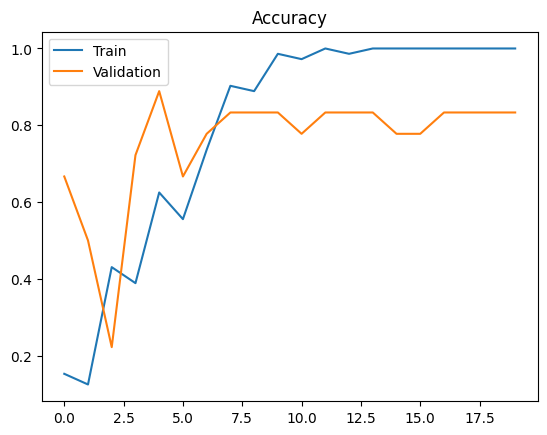

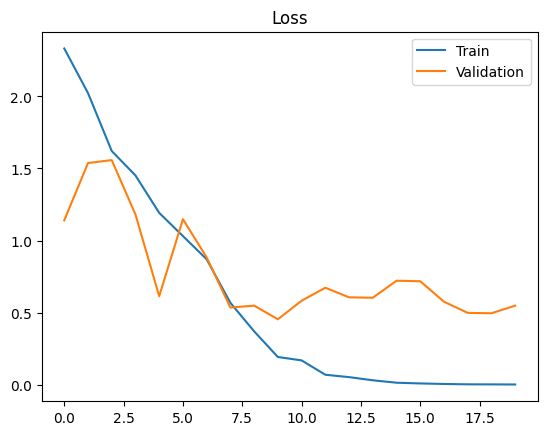

In [20]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()